In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [2]:
import tensorflow as tf
from tensorflow import keras

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from src.dataset import (
    create_datasets,
    compute_class_weights,
    get_data_augmentation,
    get_class_names
)

In [3]:
train_ds, val_ds, test_ds = create_datasets()
class_name = ['angry',
 'disgust',
 'fear',
 'happy',
 'neutral',
 'sad',
 'surprise']

model = keras.models.load_model("../models/best_model.keras")

model.summary()


Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Found 7178 files belonging to 7 classes.


Model: "EmotionCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 3,722,615 (14.20 MB)

 Trainable params: 1,240,231 (4.73 MB)

 Non-trainable params: 1,920 (7.50 KB)

 Optimizer params: 2,480,464 (9.46 MB)

In [4]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - accuracy: 0.5812 - loss: 1.1117
Test Loss     : 1.1117
Test Accuracy : 0.5812


In [5]:
y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())

    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [6]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_name
    )
)

              precision    recall  f1-score   support

       angry       0.48      0.47      0.48       958
     disgust       0.23      0.71      0.35       111
        fear       0.42      0.23      0.30      1024
       happy       0.89      0.77      0.83      1774
     neutral       0.50      0.68      0.58      1233
         sad       0.47      0.43      0.45      1247
    surprise       0.66      0.81      0.73       831

    accuracy                           0.58      7178
   macro avg       0.52      0.58      0.53      7178
weighted avg       0.59      0.58      0.58      7178



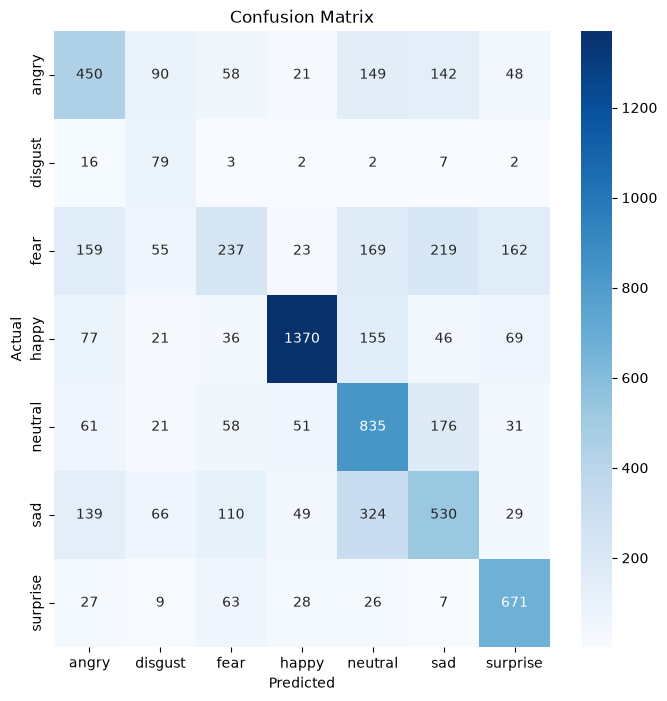

In [7]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_name,
    yticklabels=class_name
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [8]:
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

for emotion, accuracy in zip(class_name, per_class_accuracy):

    print(f"{emotion:<10} : {accuracy:.2%}")

angry      : 46.97%
disgust    : 71.17%
fear       : 23.14%
happy      : 77.23%
neutral    : 67.72%
sad        : 42.50%
surprise   : 80.75%


In [9]:
wrong_images = []
wrong_true = []
wrong_pred = []

for images, labels in test_ds:

    predictions = model.predict(images, verbose=0)

    predicted = np.argmax(predictions, axis=1)

    mask = predicted != labels.numpy()

    wrong_images.extend(images.numpy()[mask])

    wrong_true.extend(labels.numpy()[mask])

    wrong_pred.extend(predicted[mask])

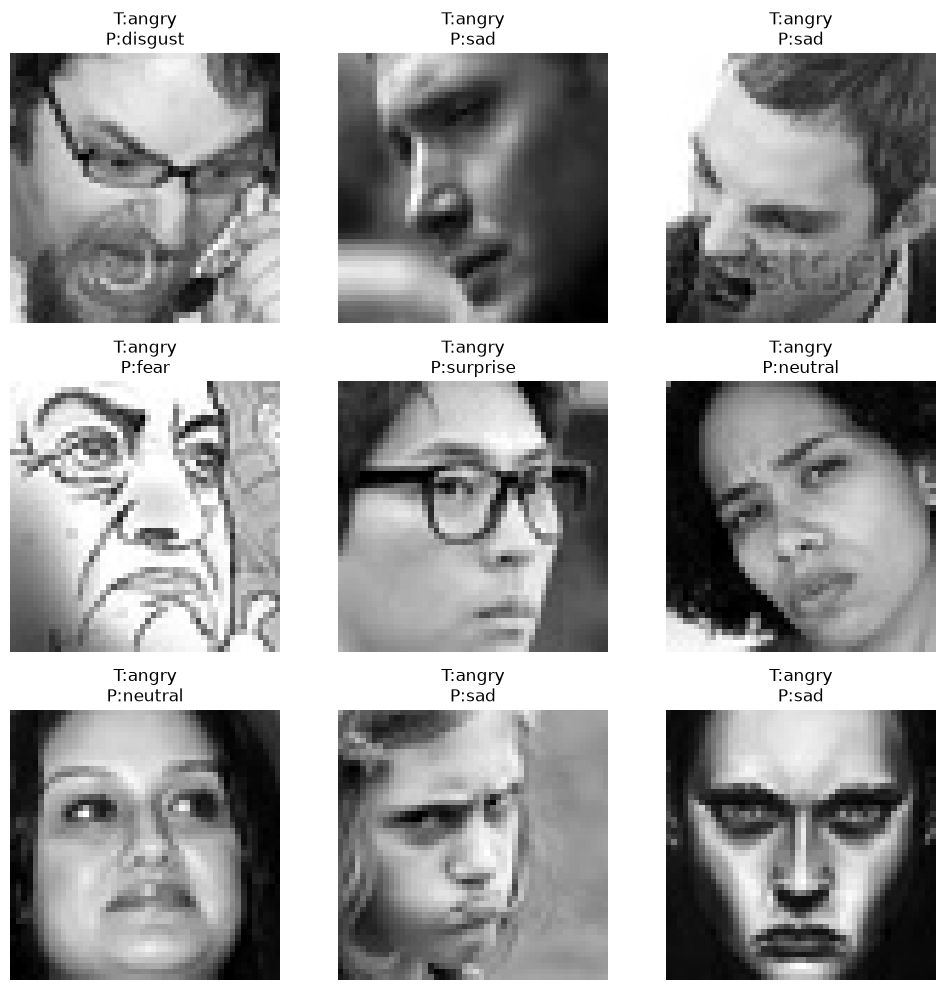

In [10]:
plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(
        wrong_images[i].squeeze(),
        cmap="gray"
    )

    plt.title(
        f"T:{class_name[wrong_true[i]]}\nP:{class_name[wrong_pred[i]]}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

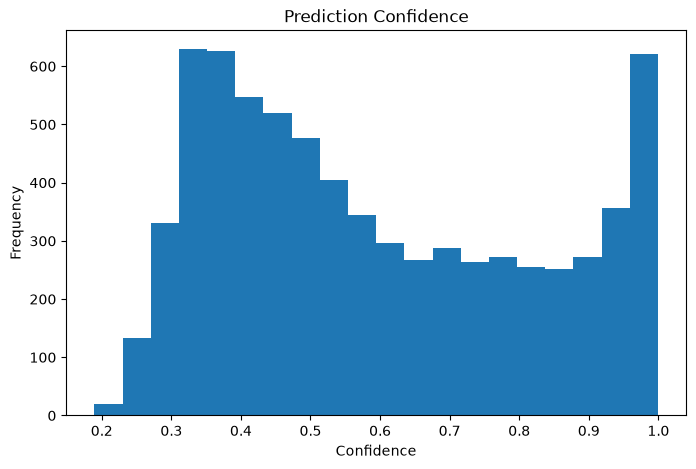

In [11]:
confidences = []

for images, _ in test_ds:

    predictions = model.predict(images, verbose=0)

    confidences.extend(
        np.max(predictions, axis=1)
    )

plt.figure(figsize=(8,5))

plt.hist(
    confidences,
    bins=20
)

plt.xlabel("Confidence")

plt.ylabel("Frequency")

plt.title("Prediction Confidence")

plt.show()